# Pattani Flood Exposure: Exploratory Geospatial Case Study

**Business question:** Where do observed historical flood geometries intersect Pattani road segments and healthcare address-text candidates, and how does that pattern vary across 2011–2024?

This portfolio analysis demonstrates a reproducible geospatial workflow: immutable source lineage, structural validation, deterministic transformation, spatial intersection, temporal aggregation, and responsible communication. It does **not** measure confirmed disruption, damage, accessibility, risk, causation, or exhaustive coverage.

## Data sources and interpretation boundary

- **Flood history:** 112,073 credential-sanitized GISTDA flood-frequency features from the completed Pattani run.
- **Roads:** 32,358 clipped OSM road **segments** derived from a reviewed Geofabrik Thailand snapshot; segments are not unique roads and category labels do not establish drivability.
- **Healthcare:** 138 DGA **address-text candidates**; these are not verified facilities or complete healthcare coverage.

Official GISTDA and DGA CRS evidence remains unresolved. Spatial comparison follows the project's reviewed exploratory RFC 7946 interpretation only. Annual values are separate observations and must not be summed as unique infrastructure totals.

In [1]:
from pathlib import Path
import csv, hashlib, io, json
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

ANALYSIS_ROOT = Path('data/processed/analysis/pattani')
PHASE4A = ANALYSIS_ROOT / 'exploratory-exposure-v1-20260925-01'
PHASE4B = ANALYSIS_ROOT / 'temporal-exposure-v1-20260926-01'
CHART_ROOT = Path('docs/assets/portfolio')
CHART_ROOT.mkdir(parents=True, exist_ok=True)

def manifest_bytes(directory, name):
    manifest = json.loads((directory / 'analysis_manifest.json').read_text(encoding='utf-8'))
    assert manifest['status'] == 'complete'
    descriptor = manifest['outputs'][name]
    content = (directory / name).read_bytes()
    assert len(content) == descriptor['byte_count']
    assert hashlib.sha256(content).hexdigest() == descriptor['sha256']
    return content

exposure = json.loads(manifest_bytes(PHASE4A, 'exposure_summary.json'))
annual = json.loads(manifest_bytes(PHASE4B, 'annual_exposure_summary.json'))
frequency = json.loads(manifest_bytes(PHASE4B, 'frequency_consistency.json'))
category_rows = list(csv.DictReader(io.StringIO(manifest_bytes(PHASE4B, 'road_category_annual_exposure.csv').decode('utf-8'))))
years = list(range(2011, 2025))
road_annual = [annual['annual_road_exposed'][f'y_{year}'] for year in years]
health_annual = [annual['annual_healthcare_exposed'][f'y_{year}'] for year in years]
categories = [{'category': row['highway_category'], 'total': int(row['total_records']), 'exposed': int(row['ever_exposed'])} for row in category_rows]

assert exposure['input_flood_polygon_count'] == 112_073
assert exposure['roads'] == {'total': 32_358, 'exposed': 4_919, 'non_exposed': 27_439, 'intersection_count_histogram': exposure['roads']['intersection_count_histogram']}
assert exposure['healthcare']['total'] == 138 and exposure['healthcare']['exposed'] == 18 and exposure['healthcare']['non_exposed'] == 120
assert max(zip(road_annual, years)) == (4_042, 2017)
assert max(zip(health_annual, years)) == (15, 2017)
assert frequency['feature_count'] == frequency['match_count'] == 112_073
assert frequency['mismatch_count'] == frequency['missing_or_invalid_count'] == 0

COLORS = {'roads': '#087f76', 'health': '#d08700', 'other': '#c9d2cf', 'ink': '#132a2d'}
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 10, 'axes.titleweight': 'bold', 'axes.edgecolor': '#9aa7a5', 'figure.facecolor': 'white'})
def publish(fig, filename):
    path = CHART_ROOT / filename
    fig.savefig(path, dpi=144, bbox_inches='tight', facecolor='white', metadata={'Software': 'Thai Flood Disruption Intelligence'})
    plt.close(fig)
    display(Image(filename=str(path)))

{'manifests_verified': 2, 'flood_features': 112073, 'road_segments': 32358, 'healthcare_candidates': 138, 'road_categories': len(categories)}

{'manifests_verified': 2,
 'flood_features': 112073,
 'road_segments': 32358,
 'healthcare_candidates': 138,
 'road_categories': 18}

## Validation and preparation

The pipeline validated source structure before analysis, retained immutable lineage and hashes, and published outputs without overwrite. This notebook independently checks aggregate file bytes and SHA-256 values against the completed Phase 4 manifests before using them. The 112,073 flood features showed an observed structural equality between `freq` and the sum of yearly fields for all records; this is an observation, not a provider semantic contract.

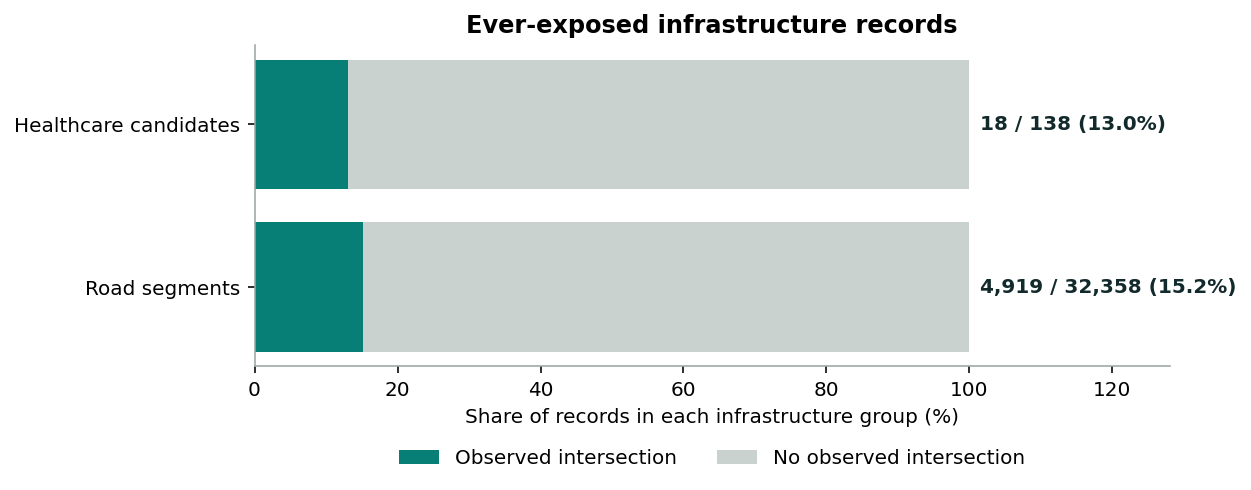

In [2]:
labels = ['Road segments', 'Healthcare candidates']
totals = [32_358, 138]
exposed = [4_919, 18]
non_exposed = [27_439, 120]
exposed_rates = [100 * hit / total for hit, total in zip(exposed, totals)]
other_rates = [100 - rate for rate in exposed_rates]
fig, ax = plt.subplots(figsize=(8.2, 3.6))
ax.barh(labels, exposed_rates, color=COLORS['roads'], label='Observed intersection')
ax.barh(labels, other_rates, left=exposed_rates, color=COLORS['other'], label='No observed intersection')
for y, (total, hit) in enumerate(zip(totals, exposed)):
    ax.text(101.5, y, f'{hit:,} / {total:,} ({hit/total:.1%})', va='center', color=COLORS['ink'], fontweight='bold')
ax.set_title('Ever-exposed infrastructure records')
ax.set(xlabel='Share of records in each infrastructure group (%)', xlim=(0, 128))
fig.subplots_adjust(bottom=.26)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(.5, -.2), ncol=2)
ax.spines[['top', 'right']].set_visible(False)
publish(fig, 'headline_exposure.png')

**Headline finding.** Geometric intersections were observed for 4,919 of 32,358 road segments (15.2%) and 18 of 138 healthcare address-text candidates (13.0%). These percentages describe records in the reviewed snapshot, not verified disruption or population impact.

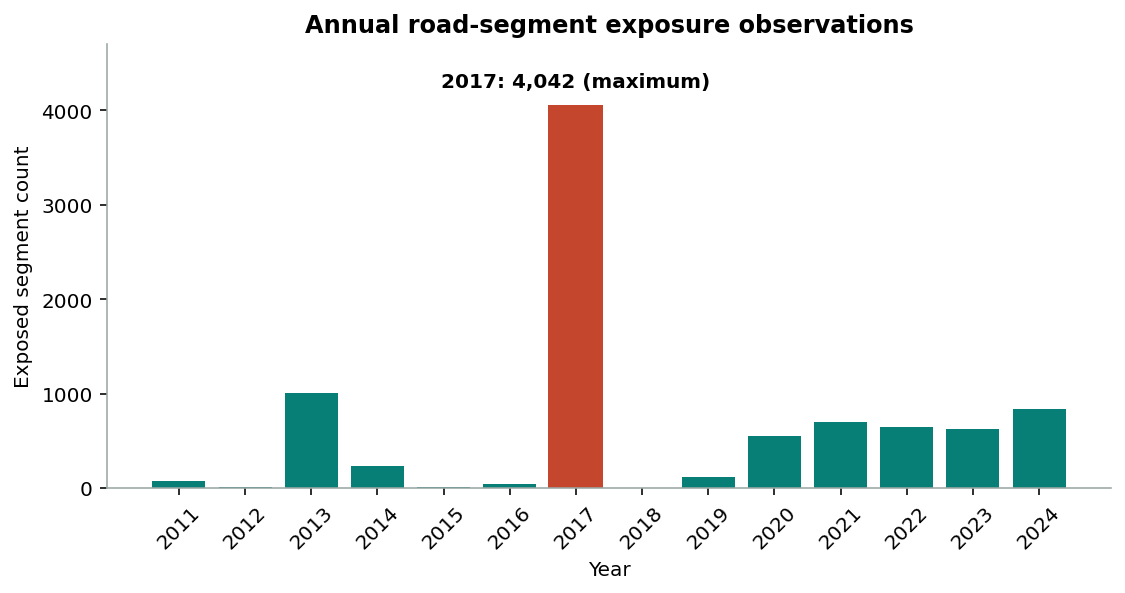

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(years, road_annual, color=COLORS['roads'])
bars[years.index(2017)].set_color('#c4472d')
ax.text(2017, 4250, '2017: 4,042 (maximum)', ha='center', fontweight='bold')
ax.set(title='Annual road-segment exposure observations', xlabel='Year', ylabel='Exposed segment count', xticks=years, ylim=(0, 4700))
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
publish(fig, 'annual_road_exposure.png')

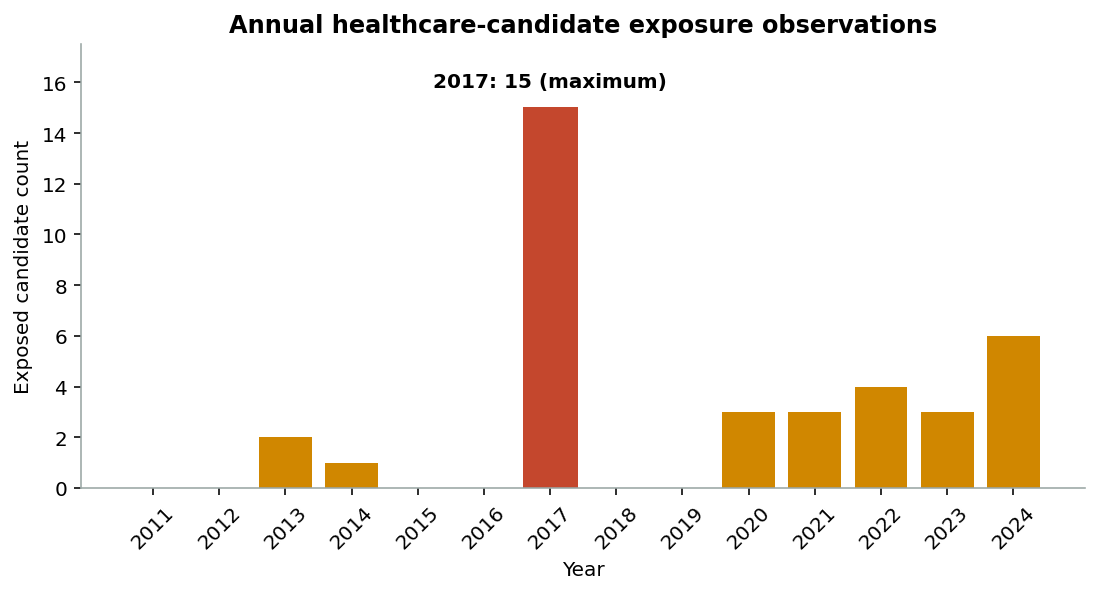

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(years, health_annual, color=COLORS['health'])
bars[years.index(2017)].set_color('#c4472d')
ax.text(2017, 15.8, '2017: 15 (maximum)', ha='center', fontweight='bold')
ax.set(title='Annual healthcare-candidate exposure observations', xlabel='Year', ylabel='Exposed candidate count', xticks=years, ylim=(0, 17.5))
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
publish(fig, 'annual_healthcare_exposure.png')

**Temporal finding.** The maximum observed annual intersection count occurred in 2017: 4,042 road segments and 15 healthcare candidates. Annual observations may overlap across years, so summing them would not produce unique infrastructure totals. A zero in 2018 is not proof that no flooding occurred.

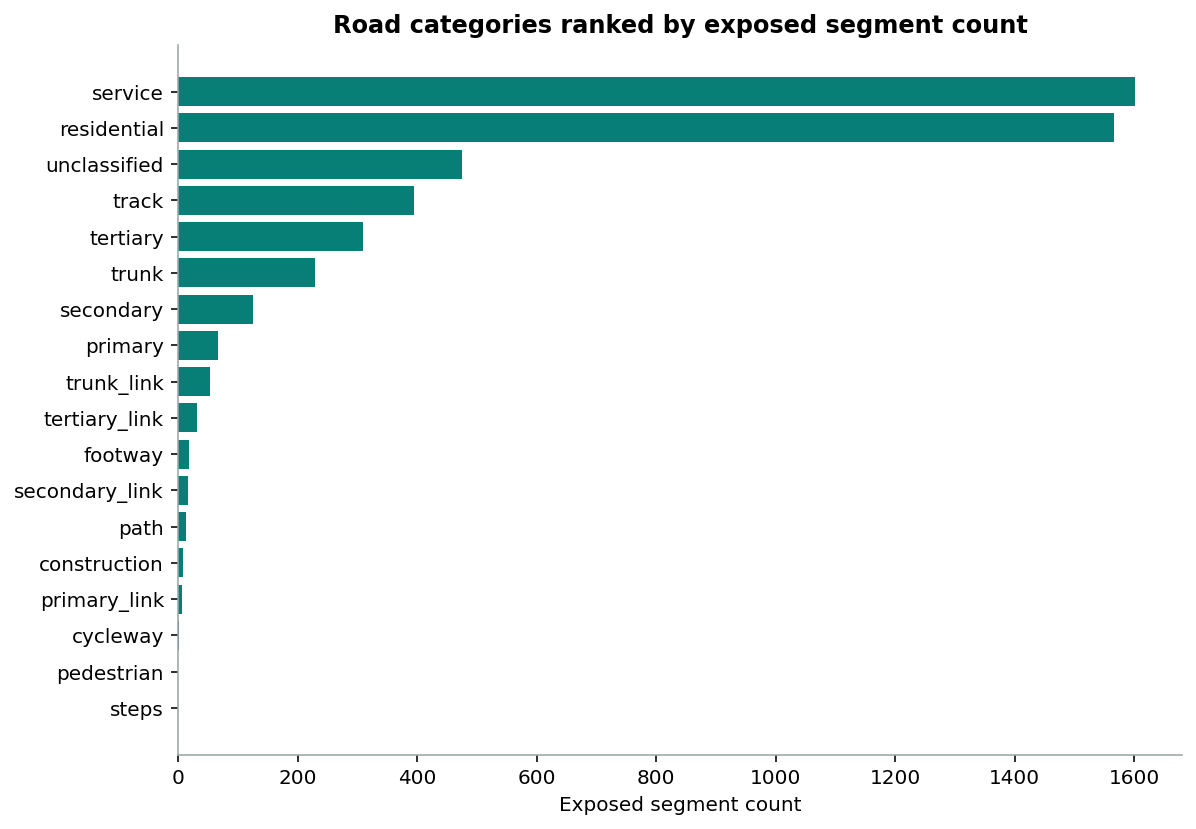

In [5]:
ranked = sorted(categories, key=lambda row: (-row['exposed'], row['category']))
fig, ax = plt.subplots(figsize=(9, 6.4))
ax.barh([row['category'] for row in reversed(ranked)], [row['exposed'] for row in reversed(ranked)], color=COLORS['roads'])
ax.set(title='Road categories ranked by exposed segment count', xlabel='Exposed segment count')
ax.spines[['top', 'right']].set_visible(False)
publish(fig, 'road_categories_exposed_count.png')

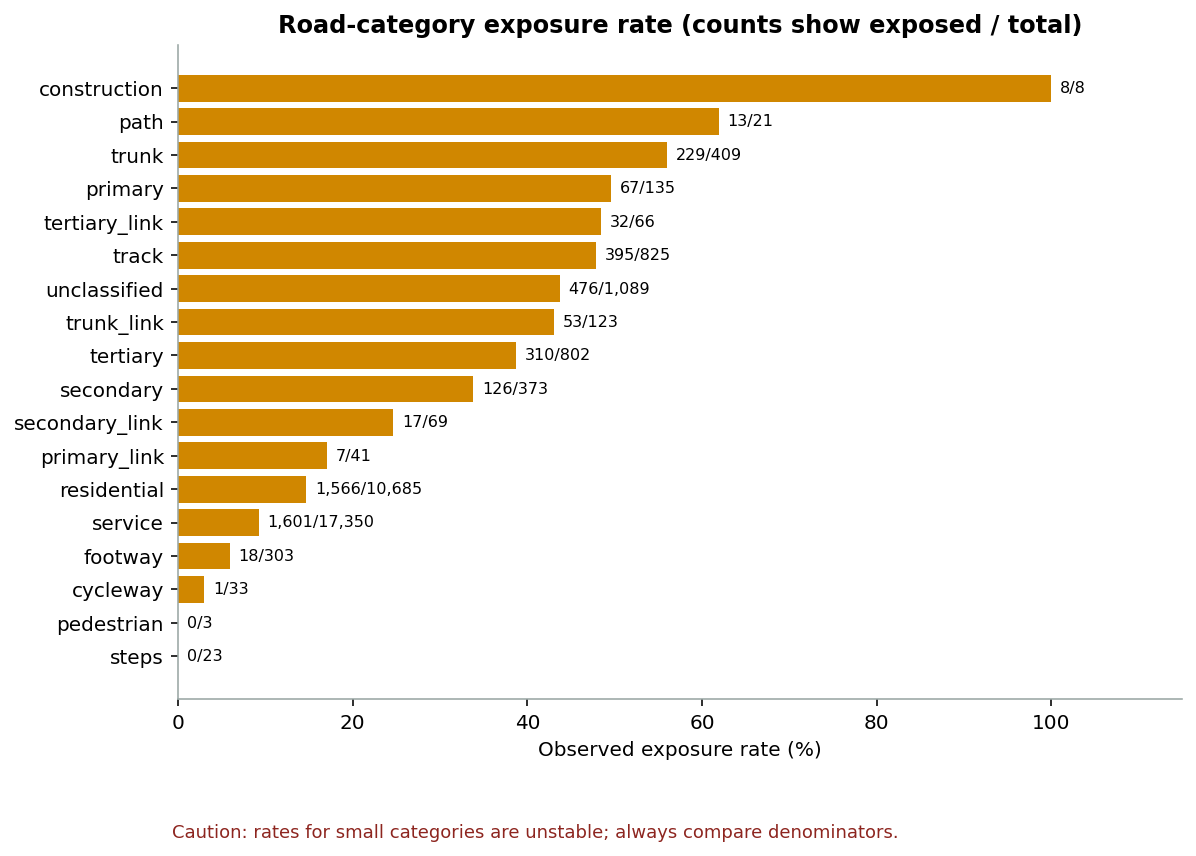

In [6]:
rate_ranked = sorted(categories, key=lambda row: (-(row['exposed']/row['total']), row['category']))
fig, ax = plt.subplots(figsize=(9, 6.4))
rates = [100 * row['exposed'] / row['total'] for row in reversed(rate_ranked)]
bars = ax.barh([row['category'] for row in reversed(rate_ranked)], rates, color=COLORS['health'])
for bar, row in zip(bars, reversed(rate_ranked)):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f"{row['exposed']:,}/{row['total']:,}", va='center', fontsize=8)
ax.set(title='Road-category exposure rate (counts show exposed / total)', xlabel='Observed exposure rate (%)', xlim=(0, 115))
fig.subplots_adjust(bottom=.17)
fig.text(.12, .02, 'Caution: rates for small categories are unstable; always compare denominators.', color='#8d251f', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
publish(fig, 'road_category_exposure_rate.png')

## Key findings and responsible interpretation

1. **Exposure is spatially selective:** 15.2% of road segments and 13.0% of healthcare candidates intersected at least one observed flood geometry.
2. **2017 dominates the observed annual series:** it had the highest recorded intersection counts for both infrastructure groups, without establishing causation or severity.
3. **Counts and rates answer different questions:** service and residential labels account for the largest exposed counts, while some small categories show high percentages driven by very small denominators.
4. **Structural consistency supports reproducibility, not semantics:** `freq` matched the yearly-field sum for 112,073 features, but the meaning of those fields remains unverified.

### Biases and uncertainty

The analysis inherits source coverage, positional accuracy, temporal alignment, and classification uncertainty. Road records are clipped segments, not unique roads; healthcare records are text-selected candidates, not verified facilities. Official CRS evidence remains unresolved, and policy completion does not prove exhaustive or snapshot-consistent provider coverage. No result should be used as an operational accessibility, response, damage, prediction, or risk claim.

## Reproducibility

The notebook uses repository-relative paths and only verified aggregate outputs. Each input is reconciled to the byte count and SHA-256 recorded in its immutable manifest before analysis. Charts are saved deterministically beneath `docs/assets/portfolio/`; no API, database, credentials, raw coordinates, feature identifiers, or interactive map are required.